# 6.34 - CertCF Hyperparameter Sweep Analysis

Focused notebook for the CertCF-only sweep in `final_benchmark_noface_certcf_shrink_sparsity.parquet`.

The goal is to understand which `(alpha, sparsity_lambda)` settings give the best tradeoff between proximity and sparsity.


In [1]:
from __future__ import annotations

from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RESULTS_DIR = ROOT / 'results'
RESULT_PATH = RESULTS_DIR / 'final_benchmark_noface_certcf_shrink_sparsity.parquet'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)

DATASET_ORDER = [
    'adult',
    'compas',
    'german_credit',
    'give_me_some_credit',
    'heloc',
    'lending_club',
    'wisconsin_breast_cancer',
]

print(RESULT_PATH)
print('exists:', RESULT_PATH.exists())


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/final_benchmark_noface_certcf_shrink_sparsity.parquet
exists: True


In [2]:
RUN_RE = re.compile(r'eps_alpha=([0-9.]+)-sparsity_lambda=([0-9.]+)')


def parse_certcf_hparams(run_name: str) -> tuple[float, float]:
    match = RUN_RE.search(str(run_name))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))


def load_certcf_sweep(path: Path = RESULT_PATH) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df = df[df['method'].astype(str).eq('certcf')].copy()
    parsed = df['run_name'].map(parse_certcf_hparams)
    df['alpha'] = [x[0] for x in parsed]
    df['sparsity_lambda'] = [x[1] for x in parsed]
    df['success_bool'] = df['success'].fillna(False).astype(bool)
    df['dataset'] = pd.Categorical(df['dataset'].astype(str), DATASET_ORDER, ordered=True)
    df = df.sort_values(['dataset', 'alpha', 'sparsity_lambda', 'query_idx'], ignore_index=True)
    return df


CERTCF_DF = load_certcf_sweep()

file_summary = pd.DataFrame({
    'rows': [len(CERTCF_DF)],
    'datasets': [CERTCF_DF['dataset'].nunique()],
    'alphas': [sorted(CERTCF_DF['alpha'].dropna().unique())],
    'sparsity_lambdas': [sorted(CERTCF_DF['sparsity_lambda'].dropna().unique())],
    'runs': [CERTCF_DF['run_name'].nunique()],
})
display(file_summary)
display(CERTCF_DF[['dataset', 'run_name', 'alpha', 'sparsity_lambda']].drop_duplicates().head(12))


,rows,datasets,alphas,sparsity_lambdas,runs
0,171828,7,"[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]","[0.1, 0.2, 0.5, 1.0]",36


,dataset,run_name,alpha,sparsity_lambda
0,adult,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,0.1000,0.1000
1000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,0.1000,0.2000
2000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,0.1000,0.5000
3000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,0.1000,1.0000
4000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.15...,0.1500,0.1000
5000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.15...,0.1500,0.2000
6000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.15...,0.1500,0.5000
7000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.15...,0.1500,1.0000
8000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.2-...,0.2000,0.1000
9000,adult,certcf_backward_shrink_sparsity_eps_alpha=0.2-...,0.2000,0.2000


## Dataset-Level Metrics


In [3]:
L0_TOL = 1e-6


def indexed_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    cols = [c for c in df.columns if c.startswith(prefix)]
    return sorted(cols, key=lambda c: int(c.rsplit('_', 1)[1]))


def add_recomputed_l0_count(df: pd.DataFrame, tol: float = L0_TOL) -> pd.DataFrame:
    out = df.copy()
    out['l0_count'] = np.nan
    out['l0_fraction_from_count'] = np.nan

    for dataset_name in DATASET_ORDER:
        mask = out['dataset'].astype(str).eq(dataset_name)
        ds = out.loc[mask]
        if ds.empty:
            continue

        orig_cols = [c for c in indexed_columns(ds, 'x_orig_') if ds[c].notna().any()]
        cf_cols = [f"x_cf_{c.rsplit('_', 1)[1]}" for c in orig_cols]
        if not orig_cols or not set(cf_cols).issubset(out.columns):
            continue

        x_orig = ds[orig_cols].to_numpy(dtype=float)
        x_cf = ds[cf_cols].to_numpy(dtype=float)
        finite = np.isfinite(x_orig).all(axis=1) & np.isfinite(x_cf).all(axis=1)
        l0 = np.full(len(ds), np.nan, dtype=float)
        l0[finite] = (np.abs(x_cf[finite] - x_orig[finite]) > tol).sum(axis=1)

        out.loc[mask, 'l0_count'] = l0
        out.loc[mask, 'l0_fraction_from_count'] = l0 / len(orig_cols)

    return out


CERTCF_DF = add_recomputed_l0_count(CERTCF_DF)


def pct_mean(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors='coerce')
    if values.notna().sum() == 0:
        return np.nan
    return float(values.fillna(False).astype(bool).mean() * 100.0)


def summarize_dataset_run(group: pd.DataFrame) -> pd.Series:
    success = group['success_bool']
    ok = group[success]
    return pd.Series({
        'n_total': int(len(group)),
        'n_success': int(success.sum()),
        'validity_pct': float(success.mean() * 100.0),
        'l1_mean': float(ok['l1_distance'].mean()) if not ok.empty else np.nan,
        'l1_median': float(ok['l1_distance'].median()) if not ok.empty else np.nan,
        'l0_count_mean': float(ok['l0_count'].mean()) if not ok.empty else np.nan,
        'l0_fraction_mean': float(ok['l0_fraction_from_count'].mean()) if not ok.empty else np.nan,
        'benchmark_l0_fraction_mean': float(ok['l0_sparsity'].mean()) if not ok.empty else np.nan,
        'fallback_pct': pct_mean(group.get('meta__nearest_anchor_fallback_used')),
        'nn_anchor_return_pct': pct_mean(group.get('meta__nearest_anchor_returned')),
        'decode_exact_pct': pct_mean(group.get('meta__decode_exact_fallback_used')),
        'sparsity_solver_calls_mean': float(pd.to_numeric(group.get('meta__sparsity_solver_calls'), errors='coerce').mean()),
        'selection_score_mean': float(pd.to_numeric(group.get('meta__sparsity_selection_score'), errors='coerce').mean()),
    })


DATASET_RUN_SUMMARY_DF = (
    CERTCF_DF
    .groupby(['dataset', 'alpha', 'sparsity_lambda', 'run_name'], observed=True)
    .apply(summarize_dataset_run)
    .reset_index()
)

display(DATASET_RUN_SUMMARY_DF.head(20).round(4))


/tmp/ipykernel_383763/1020333910.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_dataset_run)


,dataset,alpha,sparsity_lambda,run_name,n_total,n_success,validity_pct,l1_mean,l1_median,l0_count_mean,l0_fraction_mean,benchmark_l0_fraction_mean,fallback_pct,nn_anchor_return_pct,decode_exact_pct,sparsity_solver_calls_mean,selection_score_mean
0,adult,0.1000,0.1000,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,1000.0000,1000.0000,100.0000,7.1159,6.9306,7.1520,0.0688,0.0688,0.0000,0.0000,0.0000,3.0000,7.5854
1,adult,0.1000,0.2000,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,1000.0000,1000.0000,100.0000,7.1229,6.9306,7.1060,0.0683,0.0683,0.0000,0.0000,0.0000,3.0000,8.0529
2,adult,0.1000,0.5000,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,1000.0000,1000.0000,100.0000,7.1541,6.9550,7.0180,0.0675,0.0675,0.0000,0.0000,0.0000,3.0000,9.4316
3,adult,0.1000,1.0000,certcf_backward_shrink_sparsity_eps_alpha=0.1-...,1000.0000,1000.0000,100.0000,7.2022,7.0514,6.9610,0.0669,0.0669,0.0000,0.0000,0.0000,3.0000,11.6874
4,adult,0.1500,0.1000,certcf_backward_shrink_sparsity_eps_alpha=0.15...,1000.0000,1000.0000,100.0000,7.0986,6.8700,7.1060,0.0683,0.0683,0.0000,0.0000,0.0000,3.0000,7.5634
5,adult,0.1500,0.2000,certcf_backward_shrink_sparsity_eps_alpha=0.15...,1000.0000,1000.0000,100.0000,7.1045,6.8700,7.0610,0.0679,0.0679,0.0000,0.0000,0.0000,3.0000,8.0258
6,adult,0.1500,0.5000,certcf_backward_shrink_sparsity_eps_alpha=0.15...,1000.0000,1000.0000,100.0000,7.1335,6.9348,6.9810,0.0671,0.0671,0.0000,0.0000,0.0000,3.0000,9.3926
7,adult,0.1500,1.0000,certcf_backward_shrink_sparsity_eps_alpha=0.15...,1000.0000,1000.0000,100.0000,7.1857,7.0382,6.9160,0.0665,0.0665,0.0000,0.0000,0.0000,3.0000,11.6292
8,adult,0.2000,0.1000,certcf_backward_shrink_sparsity_eps_alpha=0.2-...,1000.0000,1000.0000,100.0000,7.0968,6.9222,7.0860,0.0681,0.0681,0.0000,0.0000,0.0000,3.0000,7.5598
9,adult,0.2000,0.2000,certcf_backward_shrink_sparsity_eps_alpha=0.2-...,1000.0000,1000.0000,100.0000,7.1031,6.9222,7.0460,0.0678,0.0678,0.0000,0.0000,0.0000,3.0000,8.0210


## Dataset-Averaged Summary


In [4]:
AGG_METRIC_COLS = [
    'validity_pct',
    'l1_mean',
    'l1_median',
    'l0_count_mean',
    'fallback_pct',
    'nn_anchor_return_pct',
    'decode_exact_pct',
    'sparsity_solver_calls_mean',
    'selection_score_mean',
]

AGG_SUMMARY_DF = (
    DATASET_RUN_SUMMARY_DF
    .groupby(['alpha', 'sparsity_lambda'], observed=True)
    .agg(
        n_datasets=('dataset', 'nunique'),
        **{f'{col}_avg': (col, 'mean') for col in AGG_METRIC_COLS},
        **{f'{col}_std': (col, 'std') for col in ['validity_pct', 'l1_mean', 'l0_count_mean']},
    )
    .reset_index()
)

DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'validity_pct_avg', 'l1_mean_avg', 'l0_count_mean_avg',
    'fallback_pct_avg', 'nn_anchor_return_pct_avg', 'decode_exact_pct_avg',
    'sparsity_solver_calls_mean_avg',
]

HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    ['l1_mean_avg', 'l0_count_mean_avg'],
    ascending=[True, True],
    ignore_index=True,
)

display(HYPERPARAMETER_SUMMARY_DF[DISPLAY_COLS].round(4))


,alpha,sparsity_lambda,n_datasets,validity_pct_avg,l1_mean_avg,l0_count_mean_avg,fallback_pct_avg,nn_anchor_return_pct_avg,decode_exact_pct_avg,sparsity_solver_calls_mean_avg
0,0.3000,0.1000,7,100.0000,7.4044,8.4481,0.0000,0.0000,1.4517,3.0000
1,0.5000,0.1000,7,100.0000,7.4090,8.4649,0.0000,0.0695,1.4286,3.0000
2,0.2500,0.1000,7,100.0000,7.4161,8.4932,0.0000,0.0000,1.4286,3.0000
3,0.4500,0.1000,7,100.0000,7.4167,8.5198,0.0000,0.0232,0.7374,3.0000
4,0.4000,0.1000,7,100.0000,7.4285,8.5308,0.0000,0.0232,0.8714,3.0000
5,0.3000,0.2000,7,100.0000,7.4316,8.2735,0.0000,0.0000,1.1571,3.0000
6,0.5000,0.2000,7,100.0000,7.4421,8.2401,0.0000,0.0695,1.3089,3.0000
7,0.2000,0.1000,7,100.0000,7.4428,8.6128,0.0000,0.0000,0.8714,3.0000
8,0.3500,0.1000,7,100.0000,7.4450,8.5435,0.0000,0.0000,1.1429,3.0000
9,0.4500,0.2000,7,100.0000,7.4478,8.2948,0.0000,0.0232,1.0143,3.0000


## Query Time

In [5]:
def compute_certcf_sweep_query_time(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []

    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or 'runtime_s' not in ds.columns:
            continue

        run_groups = ds.groupby(['alpha', 'sparsity_lambda', 'run_name'], observed=True)
        for (alpha, sparsity_lambda, run_name), run_df in run_groups:
            runtime_values = pd.to_numeric(run_df['runtime_s'], errors='coerce').dropna().to_numpy(dtype=float)
            build_values = pd.to_numeric(run_df.get('build_time_s'), errors='coerce').dropna().to_numpy(dtype=float)
            success_runtime_values = pd.to_numeric(
                run_df.loc[run_df['success_bool'], 'runtime_s'],
                errors='coerce',
            ).dropna().to_numpy(dtype=float)
            if len(runtime_values) == 0:
                continue

            rows.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'sparsity_lambda': float(sparsity_lambda),
                'run_name': run_name,
                'n_queries': int(len(run_df)),
                'n_success': int(run_df['success_bool'].sum()),
                'build_time_s': float(build_values[0]) if len(build_values) else np.nan,
                'mean_query_time_s': float(np.mean(runtime_values)),
                'median_query_time_s': float(np.median(runtime_values)),
                'mean_success_query_time_s': float(np.mean(success_runtime_values)) if len(success_runtime_values) else np.nan,
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_queries=('n_queries', 'sum'),
            total_success=('n_success', 'sum'),
            dataset_avg_build_time_s=('build_time_s', 'mean'),
            dataset_std_build_time_s=('build_time_s', 'std'),
            dataset_avg_query_time_s=('mean_query_time_s', 'mean'),
            dataset_std_query_time_s=('mean_query_time_s', 'std'),
            dataset_avg_median_query_time_s=('median_query_time_s', 'mean'),
            dataset_std_median_query_time_s=('median_query_time_s', 'std'),
            dataset_avg_success_query_time_s=('mean_success_query_time_s', 'mean'),
            dataset_std_success_query_time_s=('mean_success_query_time_s', 'std'),
        )
        .reset_index()
        .sort_values(['dataset_avg_query_time_s', 'dataset_avg_median_query_time_s'], ascending=[True, True], ignore_index=True)
    )
    return by_dataset, averaged


QUERY_TIME_BY_DATASET_DF, QUERY_TIME_AVERAGED_DF = compute_certcf_sweep_query_time(CERTCF_DF)
AGG_SUMMARY_DF = AGG_SUMMARY_DF.drop(
    columns=[
        'dataset_avg_build_time_s',
        'dataset_std_build_time_s',
        'dataset_avg_query_time_s',
        'dataset_std_query_time_s',
        'dataset_avg_median_query_time_s',
        'dataset_std_median_query_time_s',
        'dataset_avg_success_query_time_s',
        'dataset_std_success_query_time_s',
    ],
    errors='ignore',
).merge(
    QUERY_TIME_AVERAGED_DF[
        [
            'alpha',
            'sparsity_lambda',
            'dataset_avg_build_time_s',
            'dataset_std_build_time_s',
            'dataset_avg_query_time_s',
            'dataset_std_query_time_s',
            'dataset_avg_median_query_time_s',
            'dataset_std_median_query_time_s',
            'dataset_avg_success_query_time_s',
            'dataset_std_success_query_time_s',
        ]
    ],
    on=['alpha', 'sparsity_lambda'],
    how='left',
)

QUERY_TIME_DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'dataset_avg_build_time_s', 'dataset_std_build_time_s',
    'dataset_avg_query_time_s', 'dataset_std_query_time_s',
    'dataset_avg_median_query_time_s', 'dataset_std_median_query_time_s',
    'dataset_avg_success_query_time_s',
    'l1_mean_avg', 'l0_count_mean_avg',
]
QUERY_TIME_HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    ['dataset_avg_query_time_s', 'dataset_avg_median_query_time_s'],
    ascending=[True, True],
    ignore_index=True,
)

display(QUERY_TIME_HYPERPARAMETER_SUMMARY_DF[QUERY_TIME_DISPLAY_COLS].round(4))


,alpha,sparsity_lambda,n_datasets,dataset_avg_build_time_s,dataset_std_build_time_s,dataset_avg_query_time_s,dataset_std_query_time_s,dataset_avg_median_query_time_s,dataset_std_median_query_time_s,dataset_avg_success_query_time_s,l1_mean_avg,l0_count_mean_avg
0,0.1000,0.1000,7,14.5830,3.5217,0.2810,0.3374,0.1524,0.0760,0.2810,7.5475,9.0780
1,0.1000,0.2000,7,14.7719,3.7406,0.3124,0.3774,0.1606,0.0660,0.3124,7.5674,8.9293
2,0.4500,0.1000,7,89.1343,150.3625,0.3247,0.3913,0.1543,0.0612,0.3247,7.4167,8.5198
3,0.4000,0.1000,7,32.3528,13.2799,0.3353,0.4313,0.1530,0.0577,0.3353,7.4285,8.5308
4,0.2000,0.1000,7,21.7281,8.1492,0.3359,0.4441,0.1528,0.0607,0.3359,7.4428,8.6128
5,0.1000,0.5000,7,14.5833,3.4332,0.3387,0.4123,0.1692,0.0604,0.3387,7.6608,8.6743
6,0.2500,0.1000,7,38.9352,39.9307,0.3482,0.4423,0.1693,0.0850,0.3482,7.4161,8.4932
7,0.5000,0.1000,7,41.0648,20.4878,0.3543,0.4556,0.1612,0.0692,0.3543,7.4090,8.4649
8,0.3500,0.1000,7,30.1676,12.2032,0.3548,0.4512,0.1646,0.0782,0.3548,7.4450,8.5435
9,0.1000,1.0000,7,14.4493,3.5382,0.3561,0.4395,0.1705,0.0568,0.3561,7.7385,8.5555


## Training Hit Rate

In [6]:
from sklearn.neighbors import NearestNeighbors
from counterfactuals.benchmarks import create_default_registries

PRIVACY_HIT_L1_TOL = 1e-6


def load_privacy_train_by_dataset(dataset_order: list[str]) -> dict[str, np.ndarray]:
    registries = create_default_registries()
    train_by_dataset = {}
    for dataset_name in dataset_order:
        dataset = registries['dataset'].create(dataset_name, data_dir=str(ROOT / 'data'))
        dataset.load()
        x_train, _ = dataset.get_train()
        train_by_dataset[dataset_name] = np.asarray(x_train, dtype=np.float32)
    return train_by_dataset


def compute_certcf_sweep_training_hit_rate(
    df: pd.DataFrame,
    tol: float = PRIVACY_HIT_L1_TOL,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_by_dataset(DATASET_ORDER)
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train = train_by_dataset[dataset_name]
        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        nn = NearestNeighbors(n_neighbors=1, metric='manhattan', n_jobs=-1)
        nn.fit(x_train)

        run_groups = ds.groupby(['alpha', 'sparsity_lambda', 'run_name'], observed=True)
        for (alpha, sparsity_lambda, run_name), run_df in run_groups:
            run_df = run_df[run_df['success_bool']].copy()
            if run_df.empty:
                continue

            x_cf = run_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            x_cf = x_cf[finite]

            distances, _ = nn.kneighbors(x_cf, return_distance=True)
            min_l1 = distances[:, 0]
            hits = min_l1 <= tol

            rows.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'sparsity_lambda': float(sparsity_lambda),
                'run_name': run_name,
                'n_success': int(len(x_cf)),
                'n_training_hits': int(hits.sum()),
                'train_hit_rate_pct': 100.0 * float(hits.mean()),
                'mean_nearest_train_l1': float(np.mean(min_l1)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            total_training_hits=('n_training_hits', 'sum'),
            dataset_avg_train_hit_rate_pct=('train_hit_rate_pct', 'mean'),
            dataset_std_train_hit_rate_pct=('train_hit_rate_pct', 'std'),
            dataset_avg_nearest_train_l1=('mean_nearest_train_l1', 'mean'),
        )
        .reset_index()
        .sort_values('dataset_avg_train_hit_rate_pct', ascending=True, ignore_index=True)
    )
    return by_dataset, averaged


PRIVACY_BY_DATASET_DF, PRIVACY_AVERAGED_DF = compute_certcf_sweep_training_hit_rate(CERTCF_DF)
AGG_SUMMARY_DF = AGG_SUMMARY_DF.drop(
    columns=[
        'dataset_avg_train_hit_rate_pct',
        'dataset_std_train_hit_rate_pct',
        'dataset_avg_nearest_train_l1',
        'total_training_hits',
    ],
    errors='ignore',
).merge(
    PRIVACY_AVERAGED_DF[
        [
            'alpha',
            'sparsity_lambda',
            'dataset_avg_train_hit_rate_pct',
            'dataset_std_train_hit_rate_pct',
            'dataset_avg_nearest_train_l1',
            'total_training_hits',
        ]
    ],
    on=['alpha', 'sparsity_lambda'],
    how='left',
)

PRIVACY_DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'dataset_avg_train_hit_rate_pct', 'dataset_std_train_hit_rate_pct',
    'dataset_avg_nearest_train_l1',
    'l1_mean_avg', 'l0_count_mean_avg',
]
PRIVACY_HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    ['dataset_avg_train_hit_rate_pct', 'l1_mean_avg'],
    ascending=[True, True],
    ignore_index=True,
)

display(PRIVACY_HYPERPARAMETER_SUMMARY_DF[PRIVACY_DISPLAY_COLS].round(4))


,alpha,sparsity_lambda,n_datasets,dataset_avg_train_hit_rate_pct,dataset_std_train_hit_rate_pct,dataset_avg_nearest_train_l1,l1_mean_avg,l0_count_mean_avg
0,0.2000,0.1000,7,0.0000,0.0000,0.5467,7.4428,8.6128
1,0.1500,0.1000,7,0.0000,0.0000,0.5077,7.4668,8.7170
2,0.2000,0.2000,7,0.0000,0.0000,0.5710,7.4709,8.4170
3,0.1500,0.2000,7,0.0000,0.0000,0.5172,7.4874,8.5807
4,0.1000,0.1000,7,0.0000,0.0000,0.3975,7.5475,9.0780
5,0.2000,0.5000,7,0.0000,0.0000,0.6093,7.5580,8.1595
6,0.1000,0.2000,7,0.0000,0.0000,0.4054,7.5674,8.9293
7,0.2000,1.0000,7,0.0000,0.0000,0.6324,7.6473,8.0322
8,0.1500,1.0000,7,0.0000,0.0000,0.5564,7.6592,8.1924
9,0.1000,0.5000,7,0.0000,0.0000,0.4215,7.6608,8.6743


## Same-Class Relative Proximity Ratio

Compare the average closest same-class training distance of returned counterfactuals against the natural leave-one-out closest same-class distance among training points. Values near 1 mean the counterfactuals are spaced from training points similarly to real data; values below 1 mean they are unusually close to training samples.

In [7]:
def load_privacy_train_xy_by_dataset(dataset_order: list[str]) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    registries = create_default_registries()
    train_by_dataset = {}
    for dataset_name in dataset_order:
        dataset = registries['dataset'].create(dataset_name, data_dir=str(ROOT / 'data'))
        dataset.load()
        x_train, y_train = dataset.get_train()
        train_by_dataset[dataset_name] = (
            np.asarray(x_train, dtype=np.float32),
            np.asarray(y_train),
        )
    return train_by_dataset


def training_same_class_closest_nn_distance_distributions(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[int, np.ndarray]:
    y_train = np.asarray(y_train, dtype=int).reshape(-1)
    distributions = {}
    for label in np.unique(y_train):
        class_x = x_train[y_train == int(label)]
        if len(class_x) <= 1:
            continue
        nn = NearestNeighbors(n_neighbors=2, metric='manhattan', n_jobs=-1)
        nn.fit(class_x)
        distances, _ = nn.kneighbors(class_x, return_distance=True)
        distributions[int(label)] = np.sort(distances[:, 1].astype(float))
    return distributions


def same_class_closest_nn_distances(
    x_cf: np.ndarray,
    labels: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    reference_distributions: dict[int, np.ndarray],
) -> tuple[np.ndarray, np.ndarray]:
    labels = np.asarray(labels, dtype=int).reshape(-1)
    y_train = np.asarray(y_train, dtype=int).reshape(-1)
    nn_l1 = np.full(len(x_cf), np.nan, dtype=float)
    valid = np.zeros(len(x_cf), dtype=bool)

    for label in np.unique(labels):
        train_mask = y_train == int(label)
        cf_mask = labels == int(label)
        if int(label) not in reference_distributions or train_mask.sum() < 1 or not cf_mask.any():
            continue

        cf_indices = np.flatnonzero(cf_mask)
        nn = NearestNeighbors(n_neighbors=1, metric='manhattan', n_jobs=-1)
        nn.fit(x_train[train_mask])
        distances, _ = nn.kneighbors(x_cf[cf_mask], return_distance=True)
        nn_l1[cf_indices] = distances[:, 0].astype(float)
        valid[cf_indices] = True

    return nn_l1, valid


def compute_certcf_sweep_relative_proximity_ratio(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_xy_by_dataset(DATASET_ORDER)
    train_rows = []
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train, y_train = train_by_dataset[dataset_name]
        reference_distributions = training_same_class_closest_nn_distance_distributions(x_train, y_train)
        if not reference_distributions:
            continue

        train_reference_values = np.concatenate(list(reference_distributions.values()))
        train_mean = float(np.mean(train_reference_values))
        train_median = float(np.median(train_reference_values))
        train_rows.append({
            'dataset': dataset_name,
            'train_mean_same_class_nn_l1': train_mean,
            'train_median_same_class_nn_l1': train_median,
            'n_train_reference': int(len(train_reference_values)),
        })

        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        run_groups = ds.groupby(['alpha', 'sparsity_lambda', 'run_name'], observed=True)
        for (alpha, sparsity_lambda, run_name), run_df in run_groups:
            run_df = run_df[run_df['success_bool']].copy()
            if run_df.empty:
                continue

            x_cf = run_df[cf_cols].to_numpy(dtype=np.float32)
            labels = run_df['y_cf'].where(run_df['y_cf'].notna(), run_df['target_class']).to_numpy(dtype=int)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue

            x_cf = x_cf[finite]
            labels = labels[finite]
            nn_l1, valid = same_class_closest_nn_distances(
                x_cf=x_cf,
                labels=labels,
                x_train=x_train,
                y_train=y_train,
                reference_distributions=reference_distributions,
            )
            if not valid.any() or not np.isfinite(train_mean) or train_mean <= 0:
                continue

            nn_l1 = nn_l1[valid]
            rows.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'sparsity_lambda': float(sparsity_lambda),
                'run_name': run_name,
                'n_success': int(len(nn_l1)),
                'mean_cf_same_class_nn_l1': float(np.mean(nn_l1)),
                'median_cf_same_class_nn_l1': float(np.median(nn_l1)),
                'train_mean_same_class_nn_l1': train_mean,
                'train_median_same_class_nn_l1': train_median,
                'relative_proximity_ratio': float(np.mean(nn_l1) / train_mean),
                'median_relative_proximity_ratio': float(np.median(nn_l1) / train_median) if train_median > 0 else np.nan,
            })

    train_reference = pd.DataFrame(train_rows)
    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_relative_proximity_ratio=('relative_proximity_ratio', 'mean'),
            dataset_std_relative_proximity_ratio=('relative_proximity_ratio', 'std'),
            dataset_avg_median_relative_proximity_ratio=('median_relative_proximity_ratio', 'mean'),
            dataset_std_median_relative_proximity_ratio=('median_relative_proximity_ratio', 'std'),
            dataset_avg_cf_same_class_nn_l1=('mean_cf_same_class_nn_l1', 'mean'),
            dataset_avg_train_same_class_nn_l1=('train_mean_same_class_nn_l1', 'mean'),
        )
        .reset_index()
        .sort_values('dataset_avg_relative_proximity_ratio', ascending=False, ignore_index=True)
    )
    return train_reference, by_dataset, averaged


(
    RELATIVE_PROXIMITY_TRAIN_REFERENCE_DF,
    RELATIVE_PROXIMITY_BY_DATASET_DF,
    RELATIVE_PROXIMITY_AVERAGED_DF,
) = compute_certcf_sweep_relative_proximity_ratio(CERTCF_DF)
AGG_SUMMARY_DF = AGG_SUMMARY_DF.drop(
    columns=[
        'dataset_avg_relative_proximity_ratio',
        'dataset_std_relative_proximity_ratio',
        'dataset_avg_median_relative_proximity_ratio',
        'dataset_std_median_relative_proximity_ratio',
        'dataset_avg_cf_same_class_nn_l1',
        'dataset_avg_train_same_class_nn_l1',
    ],
    errors='ignore',
).merge(
    RELATIVE_PROXIMITY_AVERAGED_DF[
        [
            'alpha',
            'sparsity_lambda',
            'dataset_avg_relative_proximity_ratio',
            'dataset_std_relative_proximity_ratio',
            'dataset_avg_median_relative_proximity_ratio',
            'dataset_std_median_relative_proximity_ratio',
            'dataset_avg_cf_same_class_nn_l1',
            'dataset_avg_train_same_class_nn_l1',
        ]
    ],
    on=['alpha', 'sparsity_lambda'],
    how='left',
)

RELATIVE_PROXIMITY_DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'dataset_avg_relative_proximity_ratio', 'dataset_std_relative_proximity_ratio',
    'dataset_avg_median_relative_proximity_ratio', 'dataset_std_median_relative_proximity_ratio',
    'dataset_avg_cf_same_class_nn_l1', 'dataset_avg_train_same_class_nn_l1',
    'l1_mean_avg', 'l0_count_mean_avg',
]
RELATIVE_PROXIMITY_HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    'dataset_avg_relative_proximity_ratio',
    ascending=False,
    ignore_index=True,
)

display(RELATIVE_PROXIMITY_TRAIN_REFERENCE_DF.round(4))
display(RELATIVE_PROXIMITY_HYPERPARAMETER_SUMMARY_DF[RELATIVE_PROXIMITY_DISPLAY_COLS].round(4))


,dataset,train_mean_same_class_nn_l1,train_median_same_class_nn_l1,n_train_reference
0,adult,1.5843,1.0679,36178
1,compas,0.2759,0.0852,4938
2,german_credit,8.0649,7.9714,800
3,give_me_some_credit,0.1757,0.0670,120000
4,heloc,5.0344,4.9796,8369
5,lending_club,1.5393,1.2758,30823
6,wisconsin_breast_cancer,10.0119,8.7466,457


,alpha,sparsity_lambda,n_datasets,dataset_avg_relative_proximity_ratio,dataset_std_relative_proximity_ratio,dataset_avg_median_relative_proximity_ratio,dataset_std_median_relative_proximity_ratio,dataset_avg_cf_same_class_nn_l1,dataset_avg_train_same_class_nn_l1,l1_mean_avg,l0_count_mean_avg
0,0.5000,1.0000,7,0.4925,0.3306,0.6308,0.6520,1.2009,3.8123,7.5850,7.9253
1,0.5000,0.5000,7,0.4904,0.3311,0.6342,0.6676,1.1827,3.8123,7.5195,8.0095
2,0.4500,1.0000,7,0.4889,0.3257,0.6120,0.6388,1.1919,3.8123,7.6065,7.9437
3,0.4000,1.0000,7,0.4888,0.3336,0.6030,0.6512,1.1832,3.8123,7.6301,7.9580
4,0.5000,0.2000,7,0.4882,0.3218,0.6291,0.6660,1.1983,3.8123,7.4421,8.2401
5,0.4000,0.5000,7,0.4874,0.3296,0.6020,0.6520,1.1829,3.8123,7.5419,8.0847
6,0.4500,0.5000,7,0.4839,0.3184,0.6100,0.6391,1.1818,3.8123,7.5363,8.0357
7,0.3500,1.0000,7,0.4836,0.3477,0.6321,0.6949,1.1381,3.8123,7.6246,7.9965
8,0.3000,0.5000,7,0.4835,0.3324,0.6266,0.6412,1.1848,3.8123,7.5020,8.0534
9,0.3000,1.0000,7,0.4830,0.3335,0.6290,0.6396,1.1829,3.8123,7.5882,7.9365


## On-Manifoldness

In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from counterfactuals.benchmarks import create_default_registries

LOF_N_NEIGHBORS = 20
IFOREST_N_ESTIMATORS = 200
IFOREST_RANDOM_STATE = 0


def x_cf_columns_for_dim(d: int) -> list[str]:
    return [f'x_cf_{idx}' for idx in range(int(d))]


def load_train_by_dataset(dataset_order: list[str]) -> dict[str, np.ndarray]:
    registries = create_default_registries()
    train_by_dataset = {}
    for dataset_name in dataset_order:
        dataset = registries['dataset'].create(dataset_name, data_dir=str(ROOT / 'data'))
        dataset.load()
        x_train, _ = dataset.get_train()
        train_by_dataset[dataset_name] = np.asarray(x_train, dtype=np.float32)
    return train_by_dataset


def compute_certcf_sweep_manifoldness_scores(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_train_by_dataset(DATASET_ORDER)
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train = train_by_dataset[dataset_name]
        cf_cols = x_cf_columns_for_dim(x_train.shape[1])
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        lof = LocalOutlierFactor(
            n_neighbors=min(LOF_N_NEIGHBORS, max(1, len(x_train) - 1)),
            novelty=True,
            n_jobs=-1,
        )
        lof.fit(x_train)

        iforest = IsolationForest(
            n_estimators=IFOREST_N_ESTIMATORS,
            contamination='auto',
            random_state=IFOREST_RANDOM_STATE,
            n_jobs=-1,
        )
        iforest.fit(x_train)

        run_groups = ds.groupby(['alpha', 'sparsity_lambda', 'run_name'], observed=True)
        for (alpha, sparsity_lambda, run_name), run_df in run_groups:
            run_df = run_df[run_df['success_bool']].copy()
            if run_df.empty:
                continue

            x_cf = run_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            x_cf = x_cf[finite]

            lof_score = lof.score_samples(x_cf)
            positive_lof = np.maximum(-lof_score, np.finfo(float).tiny)

            rows.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'sparsity_lambda': float(sparsity_lambda),
                'run_name': run_name,
                'n_success': int(len(x_cf)),
                'log_positive_lof_mean': float(np.mean(np.log(positive_lof))),
                'iforest_score_mean': float(np.mean(iforest.score_samples(x_cf))),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_log_positive_lof=('log_positive_lof_mean', 'mean'),
            dataset_std_log_positive_lof=('log_positive_lof_mean', 'std'),
            dataset_avg_iforest_score=('iforest_score_mean', 'mean'),
            dataset_std_iforest_score=('iforest_score_mean', 'std'),
        )
        .reset_index()
        .sort_values(['dataset_avg_log_positive_lof', 'dataset_avg_iforest_score'], ascending=[True, False], ignore_index=True)
    )
    return by_dataset, averaged


MANIFOLDNESS_BY_DATASET_DF, MANIFOLDNESS_AVERAGED_DF = compute_certcf_sweep_manifoldness_scores(CERTCF_DF)
AGG_SUMMARY_DF = AGG_SUMMARY_DF.drop(
    columns=[
        'dataset_avg_negative_lof',
        'dataset_std_negative_lof',
        'dataset_avg_log_positive_lof',
        'dataset_std_log_positive_lof',
        'dataset_avg_iforest_score',
        'dataset_std_iforest_score',
    ],
    errors='ignore',
).merge(
    MANIFOLDNESS_AVERAGED_DF[
        [
            'alpha',
            'sparsity_lambda',
            'dataset_avg_log_positive_lof',
            'dataset_std_log_positive_lof',
            'dataset_avg_iforest_score',
            'dataset_std_iforest_score',
        ]
    ],
    on=['alpha', 'sparsity_lambda'],
    how='left',
)

MANIFOLDNESS_DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'dataset_avg_log_positive_lof', 'dataset_std_log_positive_lof',
    'dataset_avg_iforest_score', 'dataset_std_iforest_score',
    'l1_mean_avg', 'l0_count_mean_avg',
]
MANIFOLDNESS_HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    ['dataset_avg_log_positive_lof', 'dataset_avg_iforest_score'],
    ascending=[True, False],
    ignore_index=True,
)

display(MANIFOLDNESS_HYPERPARAMETER_SUMMARY_DF[MANIFOLDNESS_DISPLAY_COLS].round(4))


,alpha,sparsity_lambda,n_datasets,dataset_avg_log_positive_lof,dataset_std_log_positive_lof,dataset_avg_iforest_score,dataset_std_iforest_score,l1_mean_avg,l0_count_mean_avg
0,0.5000,1.0000,7,0.1088,0.1217,-0.4172,0.0320,7.5850,7.9253
1,0.5000,0.5000,7,0.1101,0.1238,-0.4173,0.0321,7.5195,8.0095
2,0.5000,0.2000,7,0.1192,0.1422,-0.4172,0.0320,7.4421,8.2401
3,0.5000,0.1000,7,0.1228,0.1495,-0.4171,0.0320,7.4090,8.4649
4,0.1000,1.0000,7,0.1438,0.2119,-0.4156,0.0317,7.7385,8.5555
5,0.1000,0.5000,7,0.1447,0.2117,-0.4158,0.0316,7.6608,8.6743
6,0.1000,0.2000,7,0.1455,0.2125,-0.4158,0.0316,7.5674,8.9293
7,0.1500,0.2000,7,0.1478,0.2154,-0.4160,0.0318,7.4874,8.5807
8,0.1500,1.0000,7,0.1490,0.2141,-0.4161,0.0314,7.6592,8.1924
9,0.2500,1.0000,7,0.1490,0.2143,-0.4170,0.0320,7.5934,7.9473


## Decision Tree Surrogate Interpretability

In [9]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

SURROGATE_TREE_MAX_DEPTH = 3
SURROGATE_TREE_MIN_SAMPLES_LEAF = 5
SURROGATE_TREE_TEST_SIZE = 0.30
SURROGATE_TREE_RANDOM_STATE = 0
SURROGATE_TREE_MIN_SAMPLES = 20
TREE_L1_SCALE_PATH = RESULTS_DIR / 'final_benchmark_noface.parquet'


def nn10000_l1_scale_by_dataset_for_sweep(
    certcf_df: pd.DataFrame,
    baseline_path: Path = TREE_L1_SCALE_PATH,
) -> pd.DataFrame:
    baseline_df = pd.read_parquet(baseline_path) if baseline_path.exists() else pd.DataFrame()
    rows = []
    for dataset in DATASET_ORDER:
        scale = np.nan
        source = 'missing'

        if not baseline_df.empty:
            ds = baseline_df[baseline_df['dataset'].astype(str).eq(dataset)]
            nn = ds[
                ds['method'].astype(str).eq('nearest_neighbor')
                & ds['success'].astype(bool)
                & ds['l1_distance'].notna()
            ]
            if not nn.empty:
                scale = float(nn['l1_distance'].mean())
                source = 'NN10000 mean successful L1'

        if not np.isfinite(scale) or scale <= 0:
            fallback = certcf_df[
                certcf_df['dataset'].astype(str).eq(dataset)
                & certcf_df['success_bool']
                & certcf_df['l1_distance'].notna()
            ]
            if not fallback.empty:
                scale = float(fallback['l1_distance'].median())
                source = 'CertCF median successful L1 fallback'

        rows.append({'dataset': dataset, 'l1_scale': scale, 'scale_source': source})
    return pd.DataFrame(rows)


TREE_L1_SCALE_DF = nn10000_l1_scale_by_dataset_for_sweep(CERTCF_DF)
display(TREE_L1_SCALE_DF.round(4))


def compute_certcf_sweep_tree_surrogate(
    df: pd.DataFrame,
    max_depth: int = SURROGATE_TREE_MAX_DEPTH,
    min_samples_leaf: int = SURROGATE_TREE_MIN_SAMPLES_LEAF,
    test_size: float = SURROGATE_TREE_TEST_SIZE,
    random_state: int = SURROGATE_TREE_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    scale_by_dataset = TREE_L1_SCALE_DF.set_index('dataset')['l1_scale'].to_dict()
    rows = []

    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty:
            continue

        orig_cols = [c for c in indexed_columns(ds, 'x_orig_') if ds[c].notna().any()]
        cf_cols = [f"x_cf_{c.rsplit('_', 1)[1]}" for c in orig_cols]
        if not orig_cols or not set(cf_cols).issubset(ds.columns):
            continue

        scale = scale_by_dataset.get(dataset_name, np.nan)
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        run_groups = ds.groupby(['alpha', 'sparsity_lambda', 'run_name'], observed=True)
        for (alpha, sparsity_lambda, run_name), run_df in run_groups:
            run_df = run_df[run_df['success_bool']].copy()
            if len(run_df) < SURROGATE_TREE_MIN_SAMPLES:
                continue

            x_query = run_df[orig_cols].to_numpy(dtype=float)
            x_cf = run_df[cf_cols].to_numpy(dtype=float)
            finite = np.isfinite(x_query).all(axis=1) & np.isfinite(x_cf).all(axis=1)
            x_query = x_query[finite]
            x_cf = x_cf[finite]
            if len(x_query) < SURROGATE_TREE_MIN_SAMPLES:
                continue

            train_idx, test_idx = train_test_split(
                np.arange(len(x_query)),
                test_size=test_size,
                random_state=random_state,
            )
            tree = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=random_state,
            )
            tree.fit(x_query[train_idx], x_cf[train_idx])
            pred = tree.predict(x_query[test_idx])
            true = x_cf[test_idx]

            l1_error = np.abs(pred - true).sum(axis=1)
            l2_error = np.linalg.norm(pred - true, axis=1)
            rows.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'sparsity_lambda': float(sparsity_lambda),
                'run_name': run_name,
                'n_success': int(len(x_query)),
                'n_test': int(len(test_idx)),
                'tree_depth': int(tree.get_depth()),
                'tree_leaves': int(tree.get_n_leaves()),
                'tree_r2': float(r2_score(true, pred, multioutput='variance_weighted')),
                'tree_l1_scale': float(scale),
                'tree_l1_error': float(np.mean(l1_error)),
                'tree_normalized_l1_error': float(np.mean(l1_error / scale)),
                'tree_l2_error': float(np.mean(l2_error)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_tree_r2=('tree_r2', 'mean'),
            dataset_std_tree_r2=('tree_r2', 'std'),
            dataset_avg_tree_l1_error=('tree_l1_error', 'mean'),
            dataset_std_tree_l1_error=('tree_l1_error', 'std'),
            dataset_avg_tree_normalized_l1_error=('tree_normalized_l1_error', 'mean'),
            dataset_std_tree_normalized_l1_error=('tree_normalized_l1_error', 'std'),
            dataset_avg_tree_l2_error=('tree_l2_error', 'mean'),
            dataset_std_tree_l2_error=('tree_l2_error', 'std'),
            dataset_avg_tree_depth=('tree_depth', 'mean'),
            dataset_avg_tree_leaves=('tree_leaves', 'mean'),
        )
        .reset_index()
        .sort_values(['dataset_avg_tree_r2', 'dataset_avg_tree_normalized_l1_error'], ascending=[False, True], ignore_index=True)
    )
    return by_dataset, averaged


TREE_SURROGATE_BY_DATASET_DF, TREE_SURROGATE_AVERAGED_DF = compute_certcf_sweep_tree_surrogate(CERTCF_DF)
AGG_SUMMARY_DF = AGG_SUMMARY_DF.drop(
    columns=[
        'dataset_avg_tree_r2',
        'dataset_std_tree_r2',
        'dataset_avg_tree_l1_error',
        'dataset_std_tree_l1_error',
        'dataset_avg_tree_normalized_l1_error',
        'dataset_std_tree_normalized_l1_error',
        'dataset_avg_tree_l2_error',
        'dataset_std_tree_l2_error',
        'dataset_avg_tree_depth',
        'dataset_avg_tree_leaves',
    ],
    errors='ignore',
).merge(
    TREE_SURROGATE_AVERAGED_DF[
        [
            'alpha',
            'sparsity_lambda',
            'dataset_avg_tree_r2',
            'dataset_std_tree_r2',
            'dataset_avg_tree_l1_error',
            'dataset_std_tree_l1_error',
            'dataset_avg_tree_normalized_l1_error',
            'dataset_std_tree_normalized_l1_error',
            'dataset_avg_tree_l2_error',
            'dataset_std_tree_l2_error',
            'dataset_avg_tree_depth',
            'dataset_avg_tree_leaves',
        ]
    ],
    on=['alpha', 'sparsity_lambda'],
    how='left',
)

TREE_SURROGATE_DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'dataset_avg_tree_r2', 'dataset_std_tree_r2',
    'dataset_avg_tree_normalized_l1_error', 'dataset_std_tree_normalized_l1_error',
    'dataset_avg_tree_l1_error',
    'dataset_avg_tree_depth', 'dataset_avg_tree_leaves',
    'l1_mean_avg', 'l0_count_mean_avg',
]
TREE_SURROGATE_HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    ['dataset_avg_tree_r2', 'dataset_avg_tree_normalized_l1_error'],
    ascending=[False, True],
    ignore_index=True,
)

display(TREE_SURROGATE_HYPERPARAMETER_SUMMARY_DF[TREE_SURROGATE_DISPLAY_COLS].round(4).sort_values(
    ['dataset_avg_tree_normalized_l1_error'],)
)

,dataset,l1_scale,scale_source
0,adult,4.9743,NN10000 mean successful L1
1,compas,1.1706,NN10000 mean successful L1
2,german_credit,9.8095,NN10000 mean successful L1
3,give_me_some_credit,0.7232,NN10000 mean successful L1
4,heloc,9.6318,NN10000 mean successful L1
5,lending_club,3.8771,NN10000 mean successful L1
6,wisconsin_breast_cancer,18.2385,NN10000 mean successful L1


,alpha,sparsity_lambda,n_datasets,dataset_avg_tree_r2,dataset_std_tree_r2,dataset_avg_tree_normalized_l1_error,dataset_std_tree_normalized_l1_error,dataset_avg_tree_l1_error,dataset_avg_tree_depth,dataset_avg_tree_leaves,l1_mean_avg,l0_count_mean_avg
3,0.1500,0.1000,7,0.2935,0.1676,1.4346,0.8038,6.8767,3.0000,7.1429,7.4668,8.7170
34,0.1000,1.0000,7,0.2425,0.2148,1.4404,0.7376,7.4450,3.0000,7.0000,7.7385,8.5555
24,0.2000,1.0000,7,0.2695,0.1718,1.4427,0.7420,7.3375,3.0000,7.4286,7.6473,8.0322
33,0.1000,0.5000,7,0.2519,0.2005,1.4431,0.7462,7.3633,3.0000,7.4286,7.6608,8.6743
20,0.1500,1.0000,7,0.2782,0.1584,1.4446,0.7594,7.2684,3.0000,7.2857,7.6592,8.1924
31,0.1500,0.5000,7,0.2627,0.1772,1.4546,0.7677,7.3580,3.0000,7.4286,7.5792,8.3030
22,0.1500,0.2000,7,0.2724,0.1716,1.4555,0.8400,7.0180,3.0000,7.1429,7.4874,8.5807
35,0.1000,0.1000,7,0.2407,0.2143,1.4591,0.7625,7.3800,3.0000,7.2857,7.5475,9.0780
32,0.2500,1.0000,7,0.2565,0.1814,1.4609,0.7663,7.3175,3.0000,7.5714,7.5934,7.9473
6,0.1000,0.2000,7,0.2914,0.1794,1.4615,0.8283,7.1064,3.0000,7.2857,7.5674,8.9293


## Average Robustness

In [10]:
import yaml
from dataset_specs import get_tabular_dataset_spec
from scripts.benchmark import _build_torch_model_from_checkpoint

ROBUSTNESS_NUM_SIGMA = 0.05
ROBUSTNESS_CAT_FLIP_P = 0.05
ROBUSTNESS_N_PERTURBATIONS = 30
ROBUSTNESS_MAX_CFS_PER_DATASET_RUN = None
ROBUSTNESS_BATCH_SIZE = 8192
ROBUSTNESS_RANDOM_STATE = 0
CERTCF_SWEEP_CONFIG = ROOT / 'configs' / 'benchmarks' / 'final_benchmark_noface_certcf_shrink_sparsity.yaml'


def load_robustness_models(config_path: Path = CERTCF_SWEEP_CONFIG) -> dict[str, object]:
    with open(config_path, 'r') as f:
        cfg = yaml.safe_load(f)

    models = {}
    for ds_cfg in cfg['datasets']:
        dataset_name = ds_cfg['name']
        model_params = dict(ds_cfg['model']['params'])
        checkpoint = ROOT / model_params['checkpoint']
        models[dataset_name] = _build_torch_model_from_checkpoint(
            checkpoint=str(checkpoint),
            device='cpu',
            dataset_module=model_params.get('dataset_module', dataset_name),
            hidden_dims=list(model_params.get('hidden_dims', [64, 32])),
            dropout=float(model_params.get('dropout', 0.2)),
        )
    return models


def predict_in_batches(model, x: np.ndarray, batch_size: int = ROBUSTNESS_BATCH_SIZE) -> np.ndarray:
    preds = []
    for start in range(0, len(x), batch_size):
        preds.append(model.predict(x[start:start + batch_size].astype(np.float32, copy=False)))
    return np.concatenate(preds)


def snap_ohe_blocks(x: np.ndarray, categorical_slices: tuple[tuple[int, int], ...]) -> np.ndarray:
    out = x.copy()
    for start, end in categorical_slices:
        if end <= start:
            continue
        chosen = np.argmax(out[:, start:end], axis=1)
        out[:, start:end] = 0.0
        out[np.arange(len(out)), start + chosen] = 1.0
    return out


def perturb_counterfactuals(
    x_cf: np.ndarray,
    spec,
    n_perturbations: int,
    numerical_sigma: float,
    categorical_flip_p: float,
    rng: np.random.Generator,
) -> np.ndarray:
    numerical_dims = [
        start
        for feature_type, (start, end) in zip(spec.input_types, spec.feature_slices)
        if feature_type == 'numerical'
    ]
    categorical_slices = tuple(spec.categorical_slices)

    base = snap_ohe_blocks(x_cf, categorical_slices)
    perturbed = np.repeat(base, n_perturbations, axis=0)

    if numerical_dims and numerical_sigma > 0:
        noise = rng.normal(0.0, numerical_sigma, size=(len(perturbed), len(numerical_dims)))
        perturbed[:, numerical_dims] += noise

    if categorical_flip_p > 0:
        for start, end in categorical_slices:
            width = end - start
            if width <= 1:
                continue
            current = np.argmax(perturbed[:, start:end], axis=1)
            flip = rng.random(len(perturbed)) < categorical_flip_p
            if not flip.any():
                continue
            replacement = rng.integers(0, width - 1, size=int(flip.sum()))
            replacement = replacement + (replacement >= current[flip])
            perturbed[flip, start:end] = 0.0
            perturbed[np.flatnonzero(flip), start + replacement] = 1.0

    return perturbed.astype(np.float32, copy=False)


def compute_certcf_sweep_robustness(
    df: pd.DataFrame,
    numerical_sigma: float = ROBUSTNESS_NUM_SIGMA,
    categorical_flip_p: float = ROBUSTNESS_CAT_FLIP_P,
    n_perturbations: int = ROBUSTNESS_N_PERTURBATIONS,
    max_cfs_per_dataset_run: int | None = ROBUSTNESS_MAX_CFS_PER_DATASET_RUN,
    random_state: int = ROBUSTNESS_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(random_state)
    models = load_robustness_models()
    rows = []

    for dataset_name in DATASET_ORDER:
        spec = get_tabular_dataset_spec(dataset_name)
        model = models[dataset_name]
        cf_cols = [f'x_cf_{idx}' for idx in range(spec.n_features)]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        run_groups = ds.groupby(['alpha', 'sparsity_lambda', 'run_name'], observed=True)
        for (alpha, sparsity_lambda, run_name), run_df in run_groups:
            run_df = run_df[run_df['success_bool']].copy()
            if run_df.empty:
                continue
            if max_cfs_per_dataset_run is not None and len(run_df) > max_cfs_per_dataset_run:
                run_df = run_df.sample(n=max_cfs_per_dataset_run, random_state=random_state)

            x_cf = run_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            run_df = run_df.loc[finite]
            x_cf = x_cf[finite]

            targets = run_df['y_cf'].fillna(run_df['target_class']).to_numpy(dtype=int)
            x_perturbed = perturb_counterfactuals(
                x_cf=x_cf,
                spec=spec,
                n_perturbations=n_perturbations,
                numerical_sigma=numerical_sigma,
                categorical_flip_p=categorical_flip_p,
                rng=rng,
            )
            target_repeated = np.repeat(targets, n_perturbations)
            pred = predict_in_batches(model, x_perturbed)
            stable = pred == target_repeated

            rows.append({
                'dataset': dataset_name,
                'alpha': float(alpha),
                'sparsity_lambda': float(sparsity_lambda),
                'run_name': run_name,
                'n_success': int(len(x_cf)),
                'n_perturbed': int(len(x_perturbed)),
                'numerical_sigma': float(numerical_sigma),
                'categorical_flip_p': float(categorical_flip_p),
                'target_robustness_pct': 100.0 * float(np.mean(stable)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['alpha', 'sparsity_lambda'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            total_perturbed=('n_perturbed', 'sum'),
            dataset_avg_target_robustness_pct=('target_robustness_pct', 'mean'),
            dataset_std_target_robustness_pct=('target_robustness_pct', 'std'),
        )
        .reset_index()
        .sort_values('dataset_avg_target_robustness_pct', ascending=False, ignore_index=True)
    )
    return by_dataset, averaged


ROBUSTNESS_BY_DATASET_DF, ROBUSTNESS_AVERAGED_DF = compute_certcf_sweep_robustness(CERTCF_DF)
AGG_SUMMARY_DF = AGG_SUMMARY_DF.merge(
    ROBUSTNESS_AVERAGED_DF[
        [
            'alpha',
            'sparsity_lambda',
            'dataset_avg_target_robustness_pct',
            'dataset_std_target_robustness_pct',
            'total_perturbed',
        ]
    ],
    on=['alpha', 'sparsity_lambda'],
    how='left',
)

ROBUSTNESS_DISPLAY_COLS = [
    'alpha', 'sparsity_lambda', 'n_datasets',
    'dataset_avg_target_robustness_pct', 'dataset_std_target_robustness_pct',
    'l1_mean_avg', 'l0_count_mean_avg',
    'dataset_avg_build_time_s', 'dataset_avg_query_time_s', 'dataset_avg_median_query_time_s',
    'dataset_avg_train_hit_rate_pct', 'dataset_avg_relative_proximity_ratio',
    'dataset_avg_log_positive_lof', 'dataset_avg_iforest_score',
    'dataset_avg_tree_r2', 'dataset_avg_tree_normalized_l1_error',
]
ROBUSTNESS_HYPERPARAMETER_SUMMARY_DF = AGG_SUMMARY_DF.sort_values(
    'dataset_avg_target_robustness_pct',
    ascending=False,
    ignore_index=True,
)

display(ROBUSTNESS_HYPERPARAMETER_SUMMARY_DF[ROBUSTNESS_DISPLAY_COLS].round(4))


,alpha,sparsity_lambda,n_datasets,dataset_avg_target_robustness_pct,dataset_std_target_robustness_pct,l1_mean_avg,l0_count_mean_avg,dataset_avg_build_time_s,dataset_avg_query_time_s,dataset_avg_median_query_time_s,dataset_avg_train_hit_rate_pct,dataset_avg_relative_proximity_ratio,dataset_avg_log_positive_lof,dataset_avg_iforest_score,dataset_avg_tree_r2,dataset_avg_tree_normalized_l1_error
0,0.2000,1.0000,7,92.2223,5.6058,7.6473,8.0322,22.2594,0.4296,0.1989,0.0000,0.4560,0.1502,-0.4168,0.2695,1.4427
1,0.3500,1.0000,7,92.1853,5.6309,7.6246,7.9965,30.8430,0.4114,0.1712,0.0232,0.4836,0.1668,-0.4168,0.2649,1.5043
2,0.3000,1.0000,7,92.1536,5.4702,7.5882,7.9365,27.0700,0.4308,0.1975,0.0463,0.4830,0.1635,-0.4165,0.2881,1.4892
3,0.1500,0.5000,7,92.1264,5.3608,7.5792,8.3030,17.8375,0.3854,0.1794,0.0232,0.4344,0.1494,-0.4164,0.2627,1.4546
4,0.2500,1.0000,7,92.1165,5.5941,7.5934,7.9473,37.6755,0.3982,0.1894,0.4399,0.4761,0.1490,-0.4170,0.2565,1.4609
5,0.4000,1.0000,7,92.0921,5.7431,7.6301,7.9580,33.1134,0.4190,0.1733,0.0463,0.4888,0.1656,-0.4170,0.2947,1.4645
6,0.2500,0.5000,7,92.0751,5.4949,7.5276,8.0322,37.3223,0.3731,0.1744,0.3936,0.4742,0.1506,-0.4172,0.2635,1.4717
7,0.1500,1.0000,7,92.0581,5.6307,7.6592,8.1924,17.7619,0.4075,0.1941,0.0000,0.4355,0.1490,-0.4161,0.2782,1.4446
8,0.2000,0.5000,7,92.0484,5.1703,7.5580,8.1595,22.2158,0.4070,0.1895,0.0000,0.4543,0.1504,-0.4169,0.2670,1.4760
9,0.3500,0.5000,7,91.9939,5.5772,7.5558,8.1034,30.1829,0.4058,0.1854,0.0232,0.4821,0.1673,-0.4169,0.2710,1.4984


## Pareto Frontier

Find non-dominated CertCF hyperparameter settings over proximity, sparsity, privacy, manifoldness, and surrogate interpretability. A run is on the frontier if no other run is at least as good on every selected metric and strictly better on at least one.

In [11]:
PARETO_METRIC_SPECS = [
    ('l1_mean_avg', 'L1 proximity', 'min'),
    ('l0_count_mean_avg', 'L0 sparsity', 'min'),
    ('dataset_avg_train_hit_rate_pct', 'Training hit rate', 'min'),
    ('dataset_avg_relative_proximity_ratio', 'Relative proximity ratio', 'max'),
    ('dataset_avg_log_positive_lof', 'Log positive LOF', 'min'),
    ('dataset_avg_tree_normalized_l1_error', 'Decision tree normalized L1 error', 'min'),
    ('dataset_avg_target_robustness_pct', 'Target robustness', 'max'),
]
PARETO_METRIC_BY_LABEL = {label: (col, label, direction) for col, label, direction in PARETO_METRIC_SPECS}


def pareto_frontier_mask(
    df: pd.DataFrame,
    metric_specs: list[tuple[str, str, str]],
    atol: float = 1e-12,
) -> np.ndarray:
    if not metric_specs:
        raise ValueError('Select at least one Pareto metric.')

    metric_cols = [col for col, _, _ in metric_specs]
    missing = [col for col in metric_cols if col not in df.columns]
    if missing:
        raise KeyError(f'Missing Pareto metric columns: {missing}')

    values = df[metric_cols].to_numpy(dtype=float)
    finite = np.isfinite(values).all(axis=1)
    costs = values.copy()
    for idx, (_, _, direction) in enumerate(metric_specs):
        if direction == 'max':
            costs[:, idx] *= -1.0
        elif direction != 'min':
            raise ValueError(f'Unknown Pareto direction: {direction!r}')

    mask = np.zeros(len(df), dtype=bool)
    valid_indices = np.flatnonzero(finite)
    valid_costs = costs[finite]

    for local_idx, global_idx in enumerate(valid_indices):
        point = valid_costs[local_idx]
        other = np.delete(valid_costs, local_idx, axis=0)
        if len(other) == 0:
            mask[global_idx] = True
            continue
        weakly_better = np.all(other <= point + atol, axis=1)
        strictly_better = np.any(other < point - atol, axis=1)
        dominated = np.any(weakly_better & strictly_better)
        mask[global_idx] = not dominated

    return mask


def build_pareto_summary(
    df: pd.DataFrame,
    metric_specs: list[tuple[str, str, str]],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    out['is_pareto'] = pareto_frontier_mask(out, metric_specs)

    metric_cols = [col for col, _, _ in metric_specs]
    display_cols = ['alpha', 'sparsity_lambda', 'is_pareto'] + metric_cols
    sort_cols = ['is_pareto'] + [col for col in ['l1_mean_avg', 'l0_count_mean_avg'] if col in out.columns]
    ascending = [False] + [True] * (len(sort_cols) - 1)
    sorted_df = out.sort_values(sort_cols, ascending=ascending, ignore_index=True)
    frontier_df = sorted_df[sorted_df['is_pareto']].copy().reset_index(drop=True)
    direction_df = pd.DataFrame(
        [
            {'metric': label, 'column': col, 'direction': 'higher is better' if direction == 'max' else 'lower is better'}
            for col, label, direction in metric_specs
        ]
    )
    return sorted_df[display_cols], frontier_df[display_cols], direction_df


def build_selected_pareto_summary(metric_labels: list[str] | None = None) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    metric_labels = metric_labels or [label for _, label, _ in PARETO_METRIC_SPECS]
    selected_specs = [PARETO_METRIC_BY_LABEL[label] for label in metric_labels]
    return build_pareto_summary(AGG_SUMMARY_DF, selected_specs)


PARETO_ALL_RUNS_DF, PARETO_FRONTIER_DF, PARETO_DIRECTION_DF = build_selected_pareto_summary()

try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    pareto_checkboxes = [
        widgets.Checkbox(
            value=True,
            description=label,
            indent=False,
            layout=widgets.Layout(width='360px'),
            style={'description_width': 'initial'},
        )
        for _, label, _ in PARETO_METRIC_SPECS
    ]
    pareto_output = widgets.Output()

    def selected_pareto_labels() -> list[str]:
        return [box.description for box in pareto_checkboxes if box.value]

    def render_selected_pareto(change=None):
        global PARETO_SELECTED_ALL_RUNS_DF, PARETO_SELECTED_FRONTIER_DF, PARETO_SELECTED_DIRECTION_DF
        with pareto_output:
            clear_output(wait=True)
            labels = selected_pareto_labels()
            if not labels:
                print('Select at least one metric.')
                return
            (
                PARETO_SELECTED_ALL_RUNS_DF,
                PARETO_SELECTED_FRONTIER_DF,
                PARETO_SELECTED_DIRECTION_DF,
            ) = build_selected_pareto_summary(labels)
            display(PARETO_SELECTED_DIRECTION_DF)
            print(
                f'Pareto frontier size: {len(PARETO_SELECTED_FRONTIER_DF)} / '
                f'{len(PARETO_SELECTED_ALL_RUNS_DF)} runs'
            )
            display(PARETO_SELECTED_FRONTIER_DF.round(4))

    pareto_update_button = widgets.Button(
        description='Update Pareto frontier',
        button_style='primary',
        layout=widgets.Layout(width='220px'),
    )
    pareto_update_button.on_click(render_selected_pareto)

    display(widgets.VBox([
        widgets.HTML('<b>Select metrics for the Pareto frontier</b>'),
        widgets.GridBox(
            pareto_checkboxes,
            layout=widgets.Layout(grid_template_columns='repeat(2, 380px)', grid_gap='4px 12px'),
        ),
        pareto_update_button,
        pareto_output,
    ]))
except ImportError:
    display(PARETO_DIRECTION_DF)


## Heatmaps


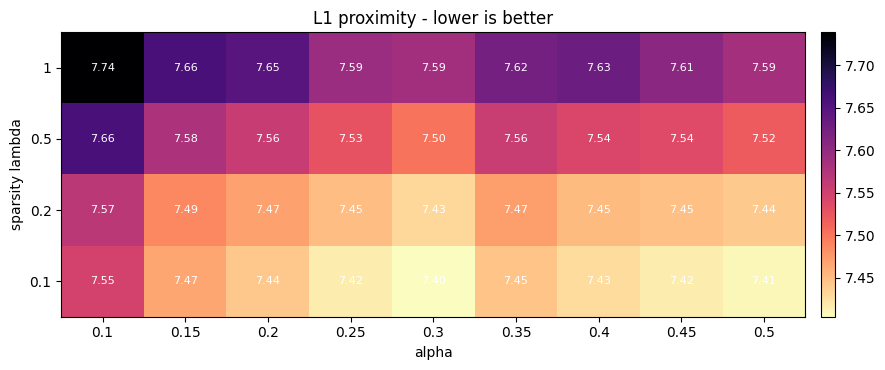

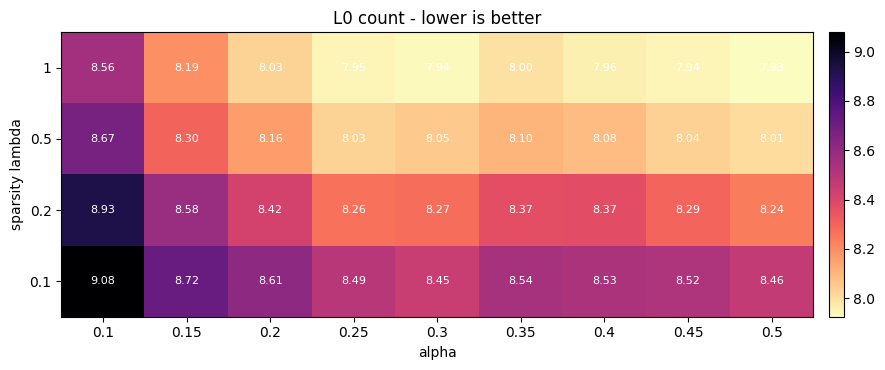

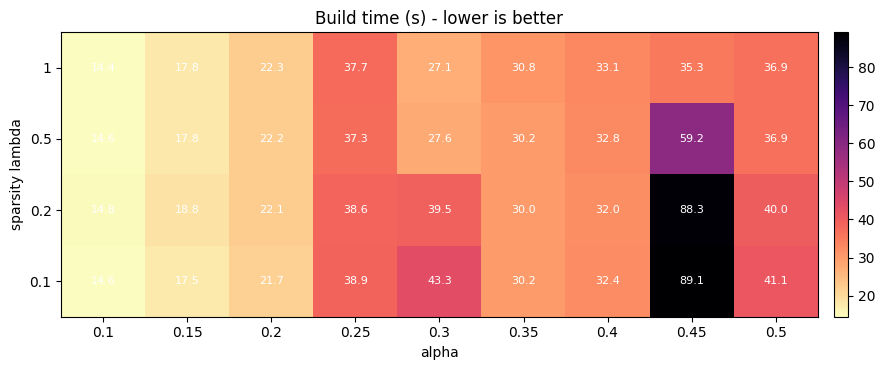

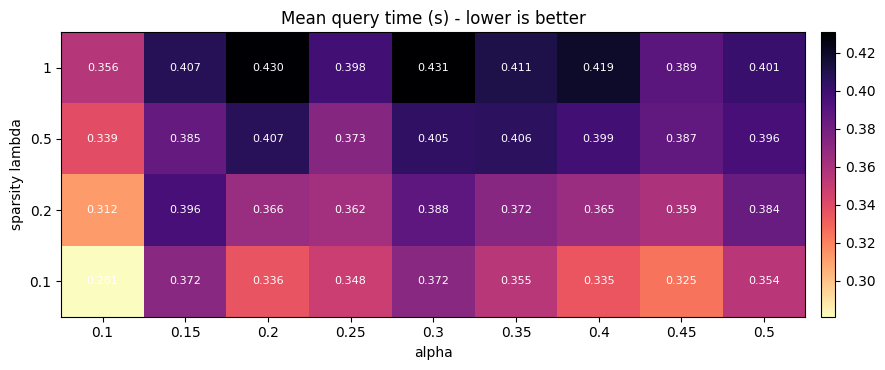

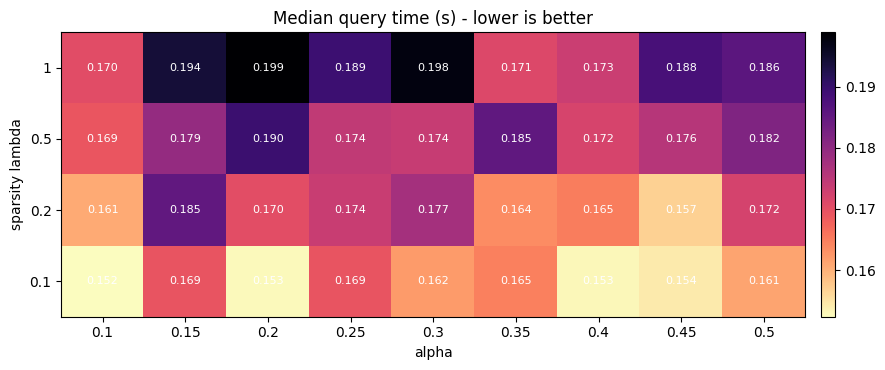

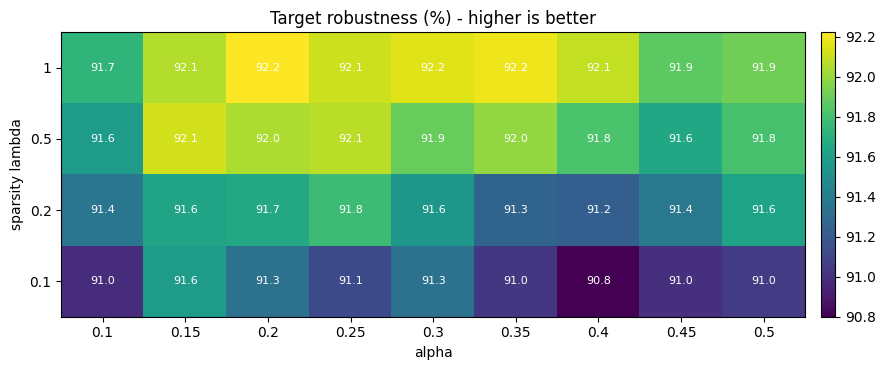

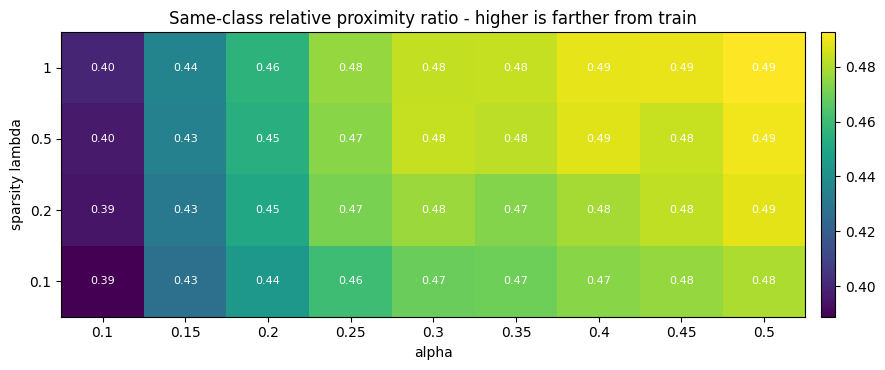

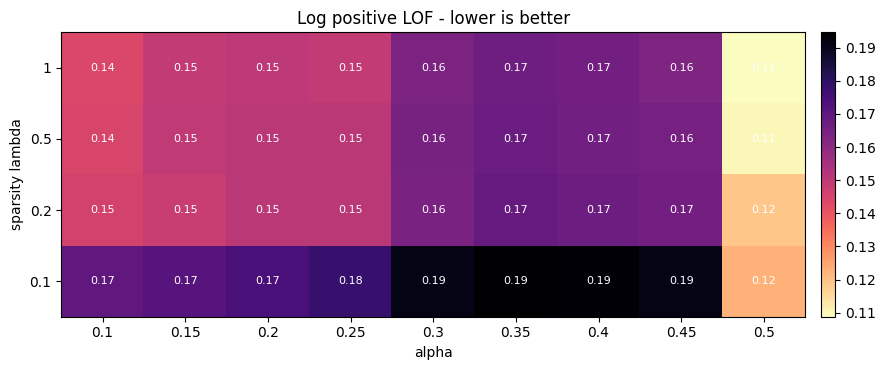

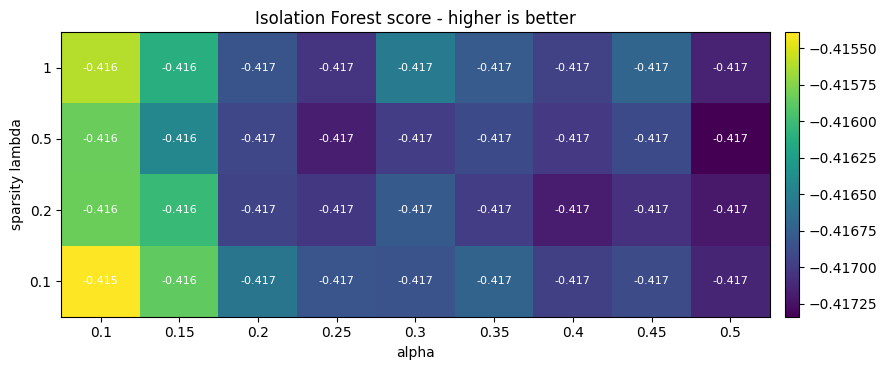

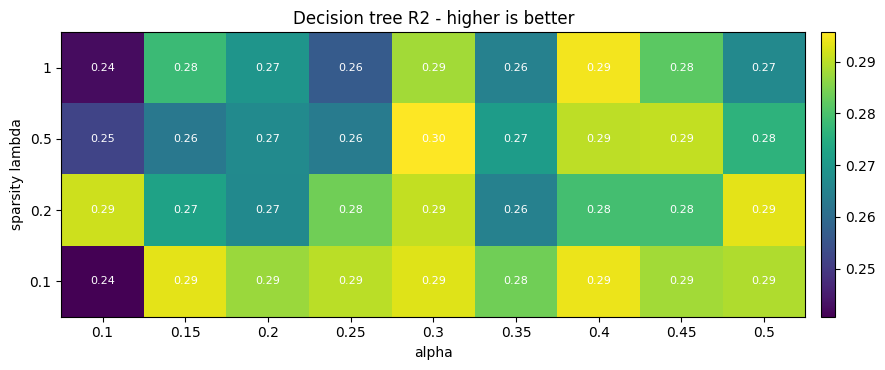

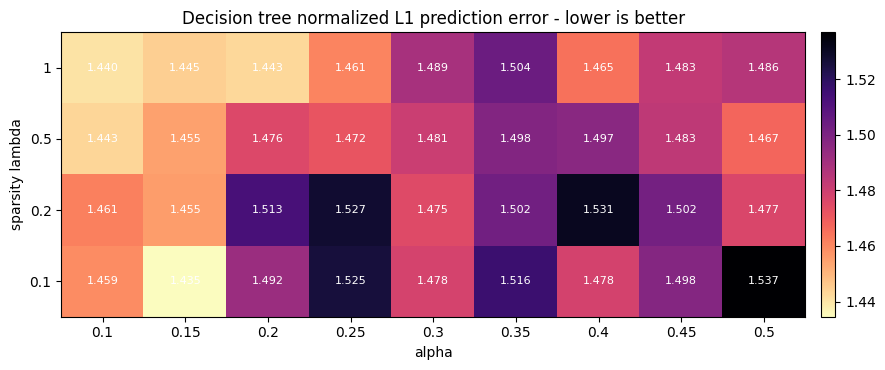

In [12]:
import matplotlib.pyplot as plt


def plot_metric_heatmap(df: pd.DataFrame, metric: str, title: str, cmap: str = 'viridis', fmt: str = '.2f'):
    pivot = df.pivot(index='sparsity_lambda', columns='alpha', values=metric).sort_index(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    data = pivot.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    ax.set_xticks(np.arange(len(pivot.columns)), [f'{x:g}' for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)), [f'{x:g}' for x in pivot.index])
    ax.set_xlabel('alpha')
    ax.set_ylabel('sparsity lambda')
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            if np.isfinite(value):
                ax.text(j, i, format(value, fmt), ha='center', va='center', fontsize=8, color='white')
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    fig.tight_layout()
    return fig, ax


plot_metric_heatmap(AGG_SUMMARY_DF, 'l1_mean_avg', 'L1 proximity - lower is better', cmap='magma_r', fmt='.2f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'l0_count_mean_avg', 'L0 count - lower is better', cmap='magma_r', fmt='.2f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_build_time_s', 'Build time (s) - lower is better', cmap='magma_r', fmt='.1f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_query_time_s', 'Mean query time (s) - lower is better', cmap='magma_r', fmt='.3f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_median_query_time_s', 'Median query time (s) - lower is better', cmap='magma_r', fmt='.3f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_target_robustness_pct', 'Target robustness (%) - higher is better', cmap='viridis', fmt='.1f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_relative_proximity_ratio', 'Same-class relative proximity ratio - higher is farther from train', cmap='viridis', fmt='.2f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_log_positive_lof', 'Log positive LOF - lower is better', cmap='magma_r', fmt='.2f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_iforest_score', 'Isolation Forest score - higher is better', cmap='viridis', fmt='.3f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_tree_r2', 'Decision tree R2 - higher is better', cmap='viridis', fmt='.2f');
plot_metric_heatmap(AGG_SUMMARY_DF, 'dataset_avg_tree_normalized_l1_error', 'Decision tree normalized L1 prediction error - lower is better', cmap='magma_r', fmt='.3f');
